# 📊 Data Science Project  

## CO₂ Emission Analysis and Prediction using Machine Learning  

**Name:** Shivangi Pundir  
**Course:** Data Science Toolbox  

**Tools Used:**  
- Python  
- Pandas  
- NumPy  
- Matplotlib  
- Seaborn  
- Scikit-learn  

---

## Objectives  

1. To perform exploratory data analysis (EDA) on CO₂ emission dataset.  
2. To visualize trends and patterns of CO₂ emissions over time.  
3. To analyze country-wise emission distribution and comparisons.  
4. To build a machine learning model for predicting CO₂ emissions.  
5. To evaluate the model using metrics such as R², MAE, and MSE.  

---

## Dataset Description  

The dataset contains historical CO₂ emission data for multiple countries across different years.  

**Key Features:**  
- **Country** – Name of the country  
- **Year** – Time period  
- **CO₂ Emissions** – Emission values  

---

## Project Workflow  

1. Data Loading and Understanding  
2. Data Cleaning and Preprocessing  
3. Exploratory Data Analysis (EDA)  
4. Data Visualization  
5. Model Building (Linear Regression)  
6. Model Evaluation  
7. Dashboard Development (Interactive Visualization)  

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

BG_COLOR = '#0f1117'
CARD_COLOR = '#1a1d2e'
ACCENT = '#00d4ff'

print("All libraries loaded!")

All libraries loaded!


In [2]:
df = pd.read_csv('owid-co2-data.csv')
print("Shape:", df.shape)
df.head()

Shape: (25204, 58)


,iso_code,country,year,co2,consumption_co2,co2_growth_prct,co2_growth_abs,trade_co2,co2_per_capita,consumption_co2_per_capita,...,ghg_per_capita,methane,methane_per_capita,nitrous_oxide,nitrous_oxide_per_capita,population,gdp,primary_energy_consumption,energy_per_capita,energy_per_gdp
0,AFG,Afghanistan,1949,0.015,NaN,NaN,NaN,NaN,0.002,NaN,...,NaN,NaN,NaN,NaN,NaN,7624058.0,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,1950,0.084,NaN,475.0,0.070,NaN,0.011,NaN,...,NaN,NaN,NaN,NaN,NaN,7752117.0,9.421400e+09,NaN,NaN,NaN
2,AFG,Afghanistan,1951,0.092,NaN,8.7,0.007,NaN,0.012,NaN,...,NaN,NaN,NaN,NaN,NaN,7840151.0,9.692280e+09,NaN,NaN,NaN
3,AFG,Afghanistan,1952,0.092,NaN,0.0,0.000,NaN,0.012,NaN,...,NaN,NaN,NaN,NaN,NaN,7935996.0,1.001732e+10,NaN,NaN,NaN
4,AFG,Afghanistan,1953,0.106,NaN,16.0,0.015,NaN,0.013,NaN,...,NaN,NaN,NaN,NaN,NaN,8039684.0,1.063052e+10,NaN,NaN,NaN


In [3]:
from IPython.display import display, HTML

rows = df.shape[0]
cols = df.shape[1]
countries = df['country'].nunique()
year_min = df['year'].min()
year_max = df['year'].max()
missing = df.isnull().sum().sum()

display(HTML(f"""
<div style="
    background-color:#0f172a;
    padding:20px;
    border-radius:12px;
    color:white;
    font-family:Arial;
    width:60%;
">
    <h2 style="color:#38bdf8;">Dataset Overview</h2>
    <hr style="border:1px solid #334155;">
    
    <p><b>Total Rows:</b> {rows:,}</p>
    <p><b>Total Columns:</b> {cols}</p>
    <p><b>Countries:</b> {countries}</p>
    <p><b>Year Range:</b> {year_min} → {year_max}</p>
    <p><b>Missing Values:</b> {missing:,}</p>
</div>
"""))

In [4]:
key_cols = ['co2', 'co2_per_capita', 'gdp', 'population', 'coal_co2', 'oil_co2', 'gas_co2']
df[key_cols].describe().round(2)

,co2,co2_per_capita,gdp,population,coal_co2,oil_co2,gas_co2
count,23949.00,23307.00,1.353800e+04,2.287800e+04,17188.00,20539.00,8845.00
mean,267.86,4.17,2.877088e+11,7.072322e+07,175.36,106.25,108.75
std,1521.68,14.91,2.180094e+12,3.795858e+08,786.11,602.68,441.06
min,0.00,0.00,5.543200e+07,1.490000e+03,0.00,0.00,0.00
25%,0.53,0.25,9.828867e+09,1.291899e+06,0.32,0.31,0.38
50%,4.86,1.25,3.037019e+10,4.880320e+06,3.98,2.10,4.20
75%,42.82,4.66,1.268944e+11,1.759622e+07,35.53,17.37,30.83
max,36702.50,748.64,1.136302e+14,7.794799e+09,15062.90,12229.64,7553.39


In [5]:
missing = df[key_cols].isnull().sum().reset_index()
missing.columns = ['Column', 'Missing Count']
missing['Missing %'] = (missing['Missing Count'] / len(df) * 100).round(2)
print(missing.to_string(index=False))

        Column  Missing Count  Missing %
           co2           1255       4.98
co2_per_capita           1897       7.53
           gdp          11666      46.29
    population           2326       9.23
      coal_co2           8016      31.80
       oil_co2           4665      18.51
       gas_co2          16359      64.91


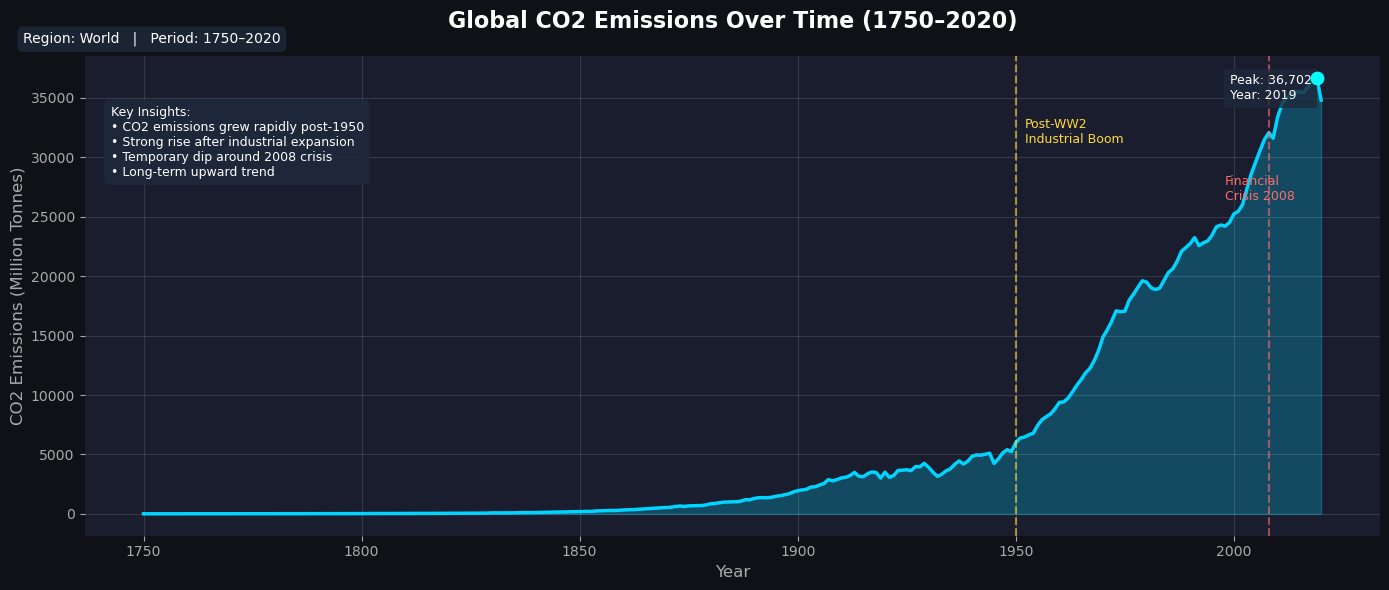

In [6]:
global_co2 = df[df['country'] == 'World'][['year', 'co2']].dropna()

fig, ax = plt.subplots(figsize=(14, 6))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(CARD_COLOR)

# Main plot
ax.fill_between(global_co2['year'], global_co2['co2'], alpha=0.25, color=ACCENT)
ax.plot(global_co2['year'], global_co2['co2'], color=ACCENT, linewidth=2.5)

# Key Events
ax.axvline(x=1950, color='#ffd93d', linestyle='--', alpha=0.6)
ax.text(1952, global_co2['co2'].max()*0.85, 
        'Post-WW2\nIndustrial Boom', 
        color='#ffd93d', fontsize=9)

ax.axvline(x=2008, color='#ff6b6b', linestyle='--', alpha=0.6)
ax.text(1998, global_co2['co2'].max()*0.72, 
        'Financial\nCrisis 2008', 
        color='#ff6b6b', fontsize=9)

# Peak Highlight
max_year = global_co2.loc[global_co2['co2'].idxmax(), 'year']
max_value = global_co2['co2'].max()

ax.scatter(max_year, max_value, color='#00ffff', s=80, zorder=5)
ax.text(max_year-20, max_value*0.95, 
        f'Peak: {int(max_value):,}\nYear: {int(max_year)}', 
        color='white',
        fontsize=9,
        bbox=dict(facecolor='#1e293b', alpha=0.8, edgecolor='none'))

# Insight Box
insight_text = (
    "Key Insights:\n"
    "• CO2 emissions grew rapidly post-1950\n"
    "• Strong rise after industrial expansion\n"
    "• Temporary dip around 2008 crisis\n"
    "• Long-term upward trend"
)

ax.text(0.02, 0.75, insight_text,
        transform=ax.transAxes,
        fontsize=9,
        color='white',
        bbox=dict(facecolor='#1e293b', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.5'))

# Fake slicer (clean UI style)
fig.text(0.02, 0.92, 
         "Region: World   |   Period: 1750–2020",
         fontsize=10,
         color='white',
         bbox=dict(facecolor='#1e293b', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.4'))

# Titles
ax.set_title('Global CO2 Emissions Over Time (1750–2020)', 
             fontsize=16, fontweight='bold', color='white', pad=20)

ax.set_xlabel('Year', fontsize=12, color='#aaaaaa')
ax.set_ylabel('CO2 Emissions (Million Tonnes)', fontsize=12, color='#aaaaaa')

# Styling
ax.tick_params(colors='#aaaaaa')
ax.grid(alpha=0.12, color='white')
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.savefig('chart1_global_trend.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

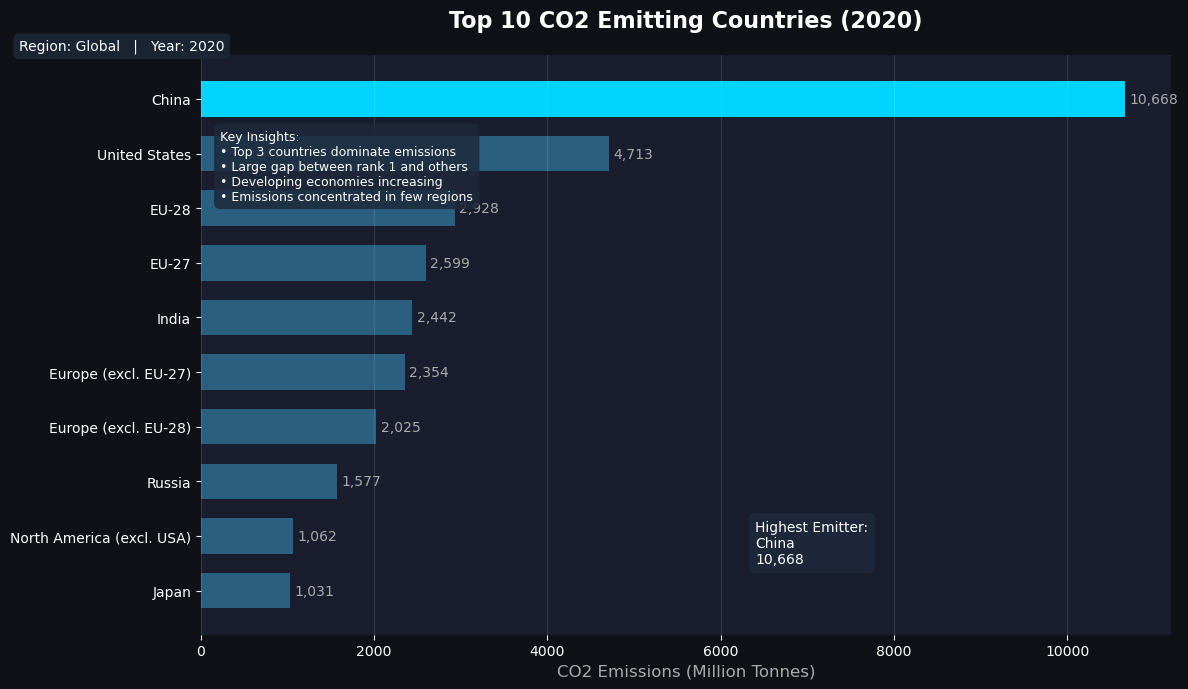

In [7]:
exclude = ['World', 'Asia', 'Europe', 'Africa', 'North America', 'South America',
           'Oceania', 'European Union (27)', 'High-income countries',
           'Low-income countries', 'Middle East', 'Asia (excl. China & India)',
           'Upper-middle-income countries', 'Lower-middle-income countries']

top10 = (df[(df['year'] == 2020) & (~df['country'].isin(exclude))]
         .nlargest(10, 'co2')[['country', 'co2']]
         .reset_index(drop=True))

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(CARD_COLOR)

# Highlight top country
bar_colors = [ACCENT] + ['#2a5f7f'] * 9

bars = ax.barh(top10['country'][::-1], top10['co2'][::-1],
               color=bar_colors[::-1], height=0.65, edgecolor='none')

# Value labels
for bar, val in zip(bars, top10['co2'][::-1]):
    ax.text(bar.get_width() + 50,
            bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}',
            va='center',
            color='#aaaaaa',
            fontsize=10)

# Highlight box for top emitter
top_country = top10.iloc[0]['country']
top_value = top10.iloc[0]['co2']

ax.text(top_value * 0.6, 0.5,
        f'Highest Emitter:\n{top_country}\n{top_value:,.0f}',
        color='white',
        fontsize=10,
        bbox=dict(facecolor='#1e293b', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.5'))

# Insight box
insight_text = (
    "Key Insights:\n"
    "• Top 3 countries dominate emissions\n"
    "• Large gap between rank 1 and others\n"
    "• Developing economies increasing\n"
    "• Emissions concentrated in few regions"
)

ax.text(0.02, 0.75, insight_text,
        transform=ax.transAxes,
        fontsize=9,
        color='white',
        bbox=dict(facecolor='#1e293b', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.5'))

# Context bar (fake slicer)
fig.text(0.02, 0.92,
         "Region: Global   |   Year: 2020",
         fontsize=10,
         color='white',
         bbox=dict(facecolor='#1e293b', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.4'))

# Titles
ax.set_title('Top 10 CO2 Emitting Countries (2020)',
             fontsize=16, fontweight='bold', color='white', pad=20)

ax.set_xlabel('CO2 Emissions (Million Tonnes)', fontsize=12, color='#aaaaaa')

# Styling
ax.tick_params(colors='white')
ax.grid(axis='x', alpha=0.12, color='white')
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.savefig('chart2_top_countries.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

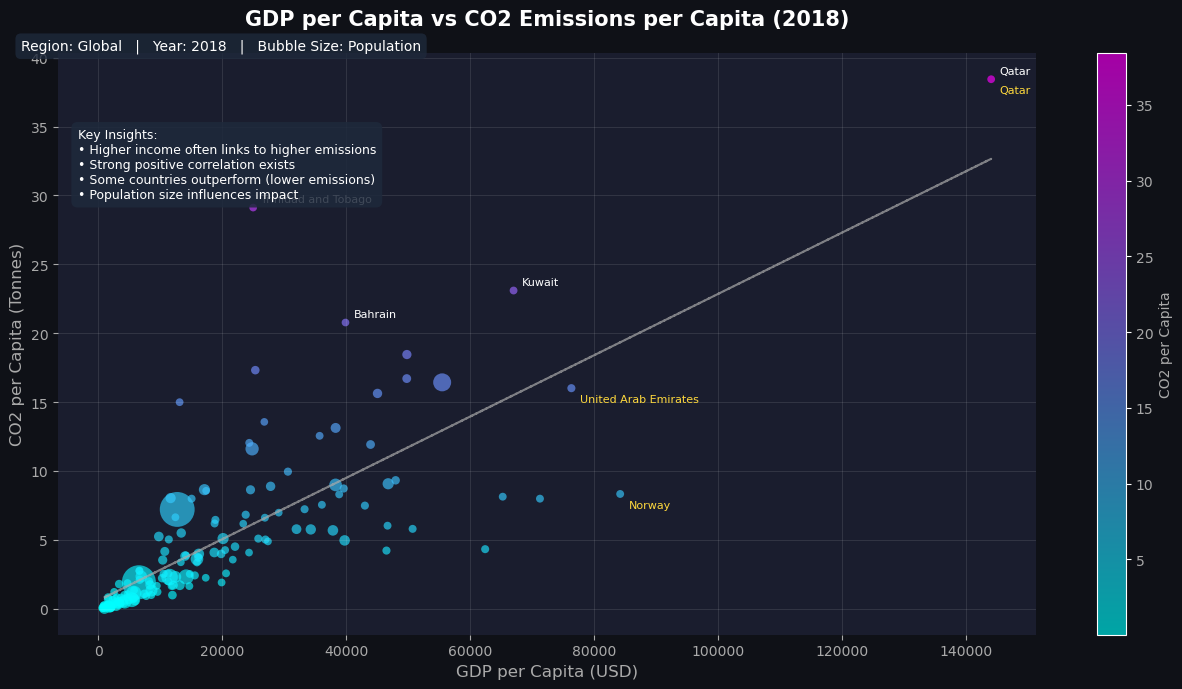

In [8]:
scatter_df = df[(df['year'] == 2018) & (~df['country'].isin(exclude))].copy()
scatter_df = scatter_df.dropna(subset=['gdp', 'population', 'co2_per_capita'])
scatter_df = scatter_df[scatter_df['population'] > 1000000]

scatter_df['gdp_per_capita'] = scatter_df['gdp'] / scatter_df['population']

scatter_df = scatter_df[
    (scatter_df['gdp_per_capita'] > 500) &
    (scatter_df['co2_per_capita'] > 0)
]

fig, ax = plt.subplots(figsize=(13, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(CARD_COLOR)

# Bubble sizes
sizes = (scatter_df['population'] / scatter_df['population'].max()) * 600 + 30

# Scatter plot
scatter = ax.scatter(
    scatter_df['gdp_per_capita'],
    scatter_df['co2_per_capita'],
    s=sizes,
    alpha=0.65,
    c=scatter_df['co2_per_capita'],
    cmap='cool',
    edgecolors='none'
)

# Highlight top emitters
for _, row in scatter_df.nlargest(4, 'co2_per_capita').iterrows():
    ax.annotate(row['country'],
                (row['gdp_per_capita'], row['co2_per_capita']),
                color='white',
                fontsize=8,
                xytext=(6, 4),
                textcoords='offset points')

# Highlight richest countries
for _, row in scatter_df.nlargest(3, 'gdp_per_capita').iterrows():
    ax.annotate(row['country'],
                (row['gdp_per_capita'], row['co2_per_capita']),
                color='#ffd93d',
                fontsize=8,
                xytext=(6, -10),
                textcoords='offset points')

# 🔥 Trend line (very important)
import numpy as np
z = np.polyfit(scatter_df['gdp_per_capita'], scatter_df['co2_per_capita'], 1)
p = np.poly1d(z)
ax.plot(scatter_df['gdp_per_capita'],
        p(scatter_df['gdp_per_capita']),
        linestyle='--',
        linewidth=1.5,
        color='#aaaaaa',
        alpha=0.7)

# Color bar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('CO2 per Capita', color='#aaaaaa')
plt.setp(cbar.ax.get_yticklabels(), color='#aaaaaa')

# 📊 Insight box
insight_text = (
    "Key Insights:\n"
    "• Higher income often links to higher emissions\n"
    "• Strong positive correlation exists\n"
    "• Some countries outperform (lower emissions)\n"
    "• Population size influences impact"
)

ax.text(0.02, 0.75, insight_text,
        transform=ax.transAxes,
        fontsize=9,
        color='white',
        bbox=dict(facecolor='#1e293b', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.5'))

# Context bar
fig.text(0.02, 0.92,
         "Region: Global   |   Year: 2018   |   Bubble Size: Population",
         fontsize=10,
         color='white',
         bbox=dict(facecolor='#1e293b', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.4'))

# Titles
ax.set_title('GDP per Capita vs CO2 Emissions per Capita (2018)',
             fontsize=15, fontweight='bold', color='white', pad=20)

ax.set_xlabel('GDP per Capita (USD)', fontsize=12, color='#aaaaaa')
ax.set_ylabel('CO2 per Capita (Tonnes)', fontsize=12, color='#aaaaaa')

# Styling
ax.tick_params(colors='#aaaaaa')
ax.grid(alpha=0.1, color='white')
ax.spines[['top','right','left','bottom']].set_visible(False)

plt.tight_layout()
plt.savefig('chart3_gdp_vs_co2.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

sources = df[df['country'] == 'World'][['year','coal_co2','oil_co2','gas_co2','cement_co2']].dropna()
sources = sources[sources['year'] >= 1900]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(CARD_COLOR)

ax.stackplot(sources['year'],
             sources['coal_co2'], sources['oil_co2'],
             sources['gas_co2'], sources['cement_co2'],
             labels=['Coal', 'Oil', 'Gas', 'Cement'],
             colors=['#4a9eff', '#ff6b6b', '#ffd93d', '#6bcb77'],
             alpha=0.85)

ax.set_title('Global CO2 by Energy Source (1900-2020)', fontsize=16, fontweight='bold', color='white', pad=20)
ax.set_xlabel('Year', fontsize=12, color='#aaaaaa')
ax.set_ylabel('CO2 Emissions (Million Tonnes)', fontsize=12, color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.grid(alpha=0.1, color='white')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.legend(loc='upper left', facecolor=CARD_COLOR, edgecolor='none', labelcolor='white', fontsize=11)

plt.tight_layout()
plt.savefig('chart4_energy_sources.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

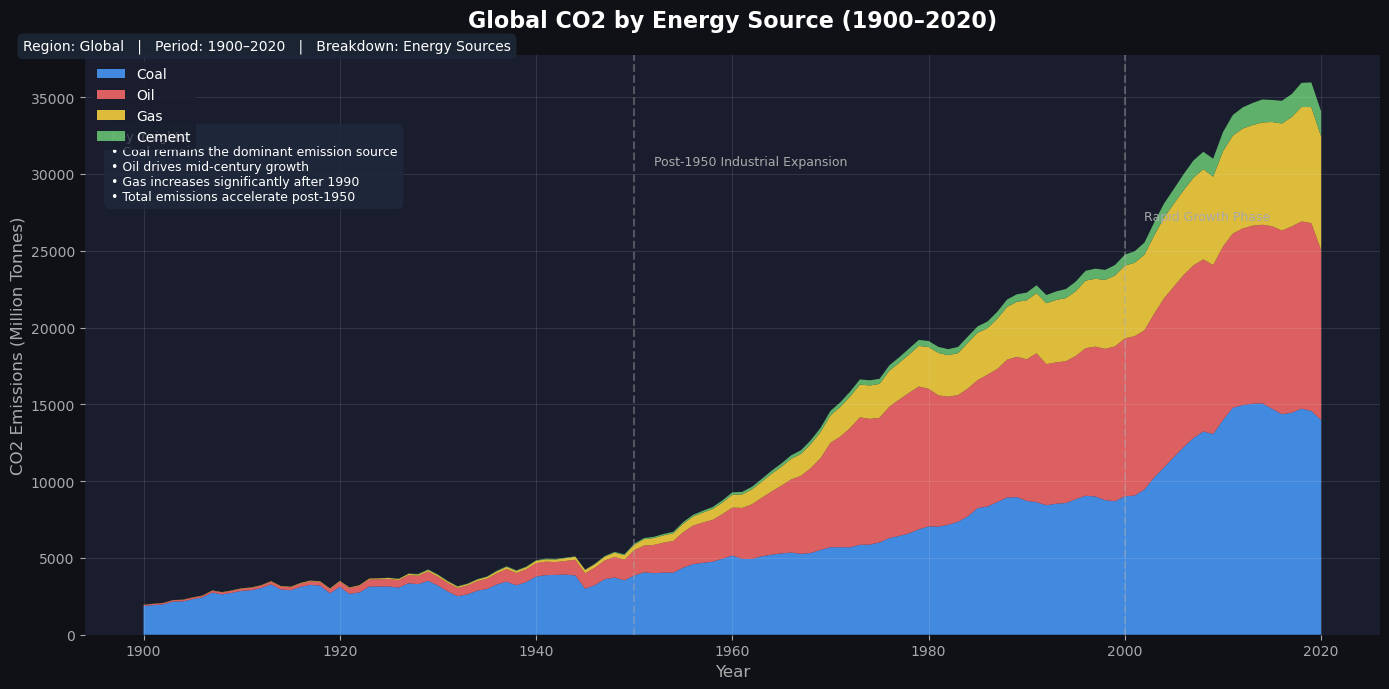

In [9]:
sources = df[df['country'] == 'World'][['year','coal_co2','oil_co2','gas_co2','cement_co2']].dropna()
sources = sources[sources['year'] >= 1900]

fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(CARD_COLOR)

# Stackplot (unchanged colors)
ax.stackplot(sources['year'],
             sources['coal_co2'], sources['oil_co2'],
             sources['gas_co2'], sources['cement_co2'],
             labels=['Coal', 'Oil', 'Gas', 'Cement'],
             colors=['#4a9eff', '#ff6b6b', '#ffd93d', '#6bcb77'],
             alpha=0.85)

# 🔥 Key period markers
ax.axvline(x=1950, color='#aaaaaa', linestyle='--', alpha=0.4)
ax.text(1952, sources[['coal_co2','oil_co2','gas_co2','cement_co2']].sum(axis=1).max()*0.85,
        'Post-1950 Industrial Expansion', color='#aaaaaa', fontsize=9)

ax.axvline(x=2000, color='#aaaaaa', linestyle='--', alpha=0.4)
ax.text(2002, sources[['coal_co2','oil_co2','gas_co2','cement_co2']].sum(axis=1).max()*0.75,
        'Rapid Growth Phase', color='#aaaaaa', fontsize=9)

# 📊 Insight box
insight_text = (
    "Key Insights:\n"
    "• Coal remains the dominant emission source\n"
    "• Oil drives mid-century growth\n"
    "• Gas increases significantly after 1990\n"
    "• Total emissions accelerate post-1950"
)

ax.text(0.02, 0.75, insight_text,
        transform=ax.transAxes,
        fontsize=9,
        color='white',
        bbox=dict(facecolor='#1e293b', alpha=0.85, edgecolor='none', boxstyle='round,pad=0.5'))

# Context bar
fig.text(0.02, 0.92,
         "Region: Global   |   Period: 1900–2020   |   Breakdown: Energy Sources",
         fontsize=10,
         color='white',
         bbox=dict(facecolor='#1e293b', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.4'))

# Titles
ax.set_title('Global CO2 by Energy Source (1900–2020)',
             fontsize=16, fontweight='bold', color='white', pad=20)

ax.set_xlabel('Year', fontsize=12, color='#aaaaaa')
ax.set_ylabel('CO2 Emissions (Million Tonnes)', fontsize=12, color='#aaaaaa')

# Styling
ax.tick_params(colors='#aaaaaa')
ax.grid(alpha=0.1, color='white')
ax.spines[['top','right','left','bottom']].set_visible(False)

# Legend (same style, slightly cleaner)
ax.legend(loc='upper left',
          facecolor=CARD_COLOR,
          edgecolor='none',
          labelcolor='white',
          fontsize=10)

plt.tight_layout()
plt.savefig('chart4_energy_sources.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

In [10]:
reg_df = df[(~df['country'].isin(exclude)) & (df['year'] >= 1990)].copy()
reg_df = reg_df.dropna(subset=['co2', 'gdp', 'population'])
reg_df = reg_df[reg_df['co2'] > 0]

X = reg_df[['gdp', 'population']]
y = reg_df['co2']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print('-'*45)
print('      REGRESSION MODEL RESULTS')
print('-'*45)
print(f'  R2 Score  : {r2:.4f}')
print(f'  MAE       : {mae:,.2f} million tonnes')
print(f'  MSE       : {mse:,.2f}')
print('-'*45)

---------------------------------------------
      REGRESSION MODEL RESULTS
---------------------------------------------
  R2 Score  : 0.8849
  MAE       : 77.37 million tonnes
  MSE       : 35,703.98
---------------------------------------------


fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(CARD_COLOR)

ax.scatter(y_test, y_pred, alpha=0.5, color=ACCENT, s=25, edgecolors='none')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val],
        color='#ff6b6b', linewidth=2, linestyle='--', label='Perfect Prediction Line')

ax.set_title(f'Actual vs Predicted CO2  |  R2 = {r2:.4f}', fontsize=15, fontweight='bold', color='white', pad=20)
ax.set_xlabel('Actual CO2 (Million Tonnes)', fontsize=12, color='#aaaaaa')
ax.set_ylabel('Predicted CO2 (Million Tonnes)', fontsize=12, color='#aaaaaa')
ax.tick_params(colors='#aaaaaa')
ax.grid(alpha=0.1, color='white')
ax.spines[['top','right','left','bottom']].set_visible(False)
ax.legend(facecolor=CARD_COLOR, edgecolor='none', labelcolor='white', fontsize=11)

metrics_text = f'R2  = {r2:.4f}\nMAE = {mae:,.0f}\nMSE = {mse:,.0f}'
ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=10, color='white',
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#2a2d3e', edgecolor='#555', alpha=0.9))

plt.tight_layout()
plt.savefig('chart5_r2_scatter.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

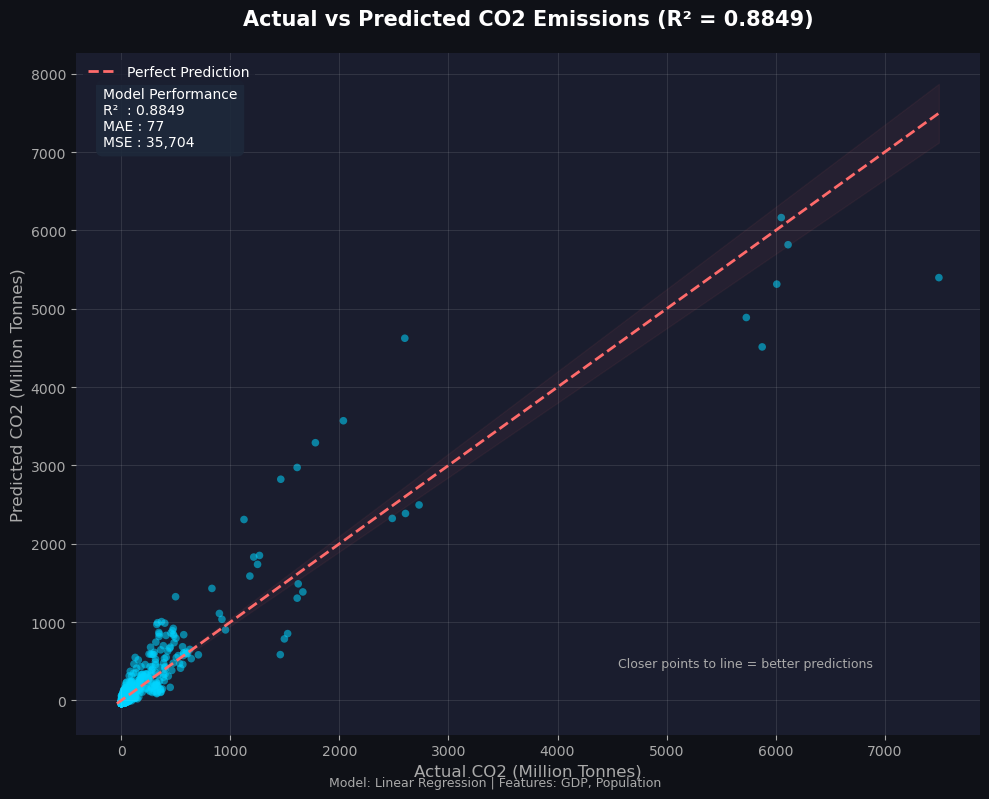

In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG_COLOR)
ax.set_facecolor(CARD_COLOR)

# Scatter
ax.scatter(y_test, y_pred,
           alpha=0.55,
           color=ACCENT,
           s=30,
           edgecolors='none')

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

ax.plot([min_val, max_val], [min_val, max_val],
        color='#ff6b6b',
        linewidth=2,
        linestyle='--',
        label='Perfect Prediction')

# 🔥 Add slight error band (very subtle but powerful)
ax.fill_between([min_val, max_val],
                [min_val*0.95, max_val*0.95],
                [min_val*1.05, max_val*1.05],
                color='#ff6b6b',
                alpha=0.05)

# Title (cleaner wording)
ax.set_title(f'Actual vs Predicted CO2 Emissions (R² = {r2:.4f})',
             fontsize=15,
             fontweight='bold',
             color='white',
             pad=20)

ax.set_xlabel('Actual CO2 (Million Tonnes)', fontsize=12, color='#aaaaaa')
ax.set_ylabel('Predicted CO2 (Million Tonnes)', fontsize=12, color='#aaaaaa')

# Styling
ax.tick_params(colors='#aaaaaa')
ax.grid(alpha=0.1, color='white')
ax.spines[['top','right','left','bottom']].set_visible(False)

# Legend
ax.legend(facecolor=CARD_COLOR,
          edgecolor='none',
          labelcolor='white',
          fontsize=10)

# 📊 Improved metrics box
metrics_text = (
    f"Model Performance\n"
    f"R²  : {r2:.4f}\n"
    f"MAE : {mae:,.0f}\n"
    f"MSE : {mse:,.0f}"
)

ax.text(0.03, 0.95,
        metrics_text,
        transform=ax.transAxes,
        fontsize=10,
        color='white',
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.5',
                  facecolor='#1e293b',
                  edgecolor='none',
                  alpha=0.9))

# 📌 Insight hint (small but powerful)
ax.text(0.6, 0.1,
        "Closer points to line = better predictions",
        transform=ax.transAxes,
        fontsize=9,
        color='#aaaaaa')

# Footer
fig.text(0.5, 0.01,
         "Model: Linear Regression | Features: GDP, Population",
         ha='center',
         fontsize=9,
         color='#aaaaaa')

plt.tight_layout()
plt.savefig('chart5_r2_scatter.png', dpi=150, bbox_inches='tight', facecolor=BG_COLOR)
plt.show()

In [12]:
world_2020 = df[(df['country'] == 'World') & (df['year'] == 2020)].iloc[0]
world_1990 = df[(df['country'] == 'World') & (df['year'] == 1990)].iloc[0]
growth = ((world_2020['co2'] - world_1990['co2']) / world_1990['co2']) * 100
top3 = df[(df['year'] == 2020) & (~df['country'].isin(exclude))].nlargest(3, 'co2')['country'].tolist()

print('-'*60)
print('          FINAL ANALYSIS - KEY FINDINGS')
print('-'*60)
print(f'\n  1. GLOBAL TREND')
print(f'     CO2 grew {growth:.1f}% from 1990 to 2020')
print(f'     2020 total: {world_2020["co2"]:,.1f} million tonnes')
print(f'\n  2. TOP EMITTERS')
print(f'     {top3[0]}, {top3[1]}, {top3[2]}')
print(f'\n  3. GDP RELATIONSHIP')
print(f'     Wealthier countries emit more CO2 per person')
print(f'\n  4. ENERGY SOURCES')
print(f'     Coal is the biggest contributor globally')
print(f'\n  5. REGRESSION MODEL')
print(f'     R2 = {r2:.4f} — model explains {r2*100:.1f}% of variance')
print(f'     MAE = {mae:,.0f} million tonnes average error')
print('-'*60)

------------------------------------------------------------
          FINAL ANALYSIS - KEY FINDINGS
------------------------------------------------------------

  1. GLOBAL TREND
     CO2 grew 53.0% from 1990 to 2020
     2020 total: 34,807.3 million tonnes

  2. TOP EMITTERS
     China, United States, EU-28

  3. GDP RELATIONSHIP
     Wealthier countries emit more CO2 per person

  4. ENERGY SOURCES
     Coal is the biggest contributor globally

  5. REGRESSION MODEL
     R2 = 0.8849 — model explains 88.5% of variance
     MAE = 77 million tonnes average error
------------------------------------------------------------


In [13]:
import subprocess
subprocess.run(['pip', 'install', 'dash', '--quiet'])
print("Done!")

Done!


In [17]:
import dash
from dash import dcc, html
import plotly.graph_objects as go
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

BG = '#0f1117'
CARD = '#1a1d2e'
ACCENT = '#00d4ff'
TEXT = '#ffffff'
SUBTEXT = '#aaaaaa'

df = pd.read_csv('owid-co2-data.csv')

exclude = ['World', 'Asia', 'Europe', 'Africa', 'North America', 'South America',
           'Oceania', 'European Union (27)', 'High-income countries',
           'Low-income countries', 'Middle East', 'Asia (excl. China & India)',
           'Upper-middle-income countries', 'Lower-middle-income countries']

global_co2 = df[df['country'] == 'World'][['year', 'co2']].dropna()

top10 = (df[(df['year'] == 2020) & (~df['country'].isin(exclude))]
         .nlargest(10, 'co2')[['country', 'co2']].reset_index(drop=True))

scatter_df = df[(df['year'] == 2018) & (~df['country'].isin(exclude))].copy()
scatter_df = scatter_df.dropna(subset=['gdp', 'population', 'co2_per_capita'])
scatter_df = scatter_df[scatter_df['population'] > 1000000]
scatter_df['gdp_per_capita'] = scatter_df['gdp'] / scatter_df['population']
scatter_df = scatter_df[(scatter_df['gdp_per_capita'] > 500) & (scatter_df['co2_per_capita'] > 0)]

sources = df[df['country'] == 'World'][['year','coal_co2','oil_co2','gas_co2','cement_co2']].dropna()
sources = sources[sources['year'] >= 1900]

reg_df = df[(~df['country'].isin(exclude)) & (df['year'] >= 1990)].copy()
reg_df = reg_df.dropna(subset=['co2', 'gdp', 'population'])
reg_df = reg_df[reg_df['co2'] > 0]
X = reg_df[['gdp', 'population']]
y = reg_df['co2']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

world_2020   = df[(df['country'] == 'World') & (df['year'] == 2020)].iloc[0]
world_2000   = df[(df['country'] == 'World') & (df['year'] == 2000)].iloc[0]
top_country  = df[(df['year'] == 2020) & (~df['country'].isin(exclude))].nlargest(1, 'co2').iloc[0]
growth       = ((world_2020['co2'] - world_2000['co2']) / world_2000['co2']) * 100

print("All data ready!")
print("R2:", round(r2, 4), "| MAE:", round(mae), "| Growth:", round(growth, 1))

All data ready!
R2: 0.8849 | MAE: 77 | Growth: 37.9


In [26]:
# World map data
# World map data - cleaned
map_df = df[(df['year'] == 2020) & (~df['country'].isin(exclude))].copy()
map_df = map_df.dropna(subset=['co2', 'iso_code'])
map_df = map_df[map_df['co2'] > 0]
map_df = map_df[map_df['iso_code'].str.len() == 3]  # keep only valid 3-letter codes
print("Map countries:", len(map_df))

Map countries: 214


In [31]:
# Trend chart
fig_trend = go.Figure()
fig_trend.add_trace(go.Scatter(
    x=global_co2['year'], y=global_co2['co2'],
    fill='tozeroy', fillcolor='rgba(0,212,255,0.15)',
    line=dict(color=ACCENT, width=2.5), name='CO2'
))
fig_trend.update_layout(
    paper_bgcolor=CARD, plot_bgcolor=CARD, height=300,
    font=dict(color=TEXT), margin=dict(l=50,r=20,t=20,b=40),
    xaxis=dict(gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
    yaxis=dict(gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
    showlegend=False
)

# Top 10 bar chart
fig_top10 = go.Figure(go.Bar(
    x=top10['co2'][::-1].values,
    y=top10['country'][::-1].values,
    orientation='h',
    marker=dict(color=['#2a5f7f']*9 + [ACCENT])
))
fig_top10.update_layout(
    paper_bgcolor=CARD, plot_bgcolor=CARD, height=370,
    font=dict(color=TEXT), margin=dict(l=120,r=40,t=20,b=40),
    xaxis=dict(gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
    yaxis=dict(color=TEXT), showlegend=False
)

# GDP scatter
fig_scatter = go.Figure(go.Scatter(
    x=scatter_df['gdp_per_capita'],
    y=scatter_df['co2_per_capita'],
    mode='markers',
    text=scatter_df['country'],
    marker=dict(
        size=np.sqrt(scatter_df['population'] / scatter_df['population'].max()) * 40 + 5,
        color=scatter_df['co2_per_capita'],
        colorscale='Teal', showscale=True, opacity=0.75
    )
))
fig_scatter.update_layout(
    paper_bgcolor=CARD, plot_bgcolor=CARD, height=370,
    font=dict(color=TEXT), margin=dict(l=50,r=60,t=20,b=50),
    xaxis=dict(title='GDP per Capita (USD)', gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
    yaxis=dict(title='CO2 per Capita (t)', gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
    showlegend=False
)

# Energy stacked area
fig_energy = go.Figure()
for col, label, color in [('coal_co2','Coal','#4a9eff'),('oil_co2','Oil','#ff6b6b'),
                            ('gas_co2','Gas','#ffd93d'),('cement_co2','Cement','#6bcb77')]:
    fig_energy.add_trace(go.Scatter(
        x=sources['year'], y=sources[col],
        stackgroup='one', name=label,
        line=dict(width=0), fillcolor=color
    ))
fig_energy.update_layout(
    paper_bgcolor=CARD, plot_bgcolor=CARD, height=370,
    font=dict(color=TEXT), margin=dict(l=50,r=20,t=20,b=40),
    xaxis=dict(gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
    yaxis=dict(gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
    legend=dict(bgcolor=CARD, font=dict(color=TEXT))
)

# R2 scatter
mn = float(min(y_test.min(), y_pred.min()))
mx = float(max(y_test.max(), y_pred.max()))
fig_r2 = go.Figure()
fig_r2.add_trace(go.Scatter(
    x=y_test, y=y_pred, mode='markers',
    marker=dict(color=ACCENT, size=5, opacity=0.5),
    name='Predictions'
))
fig_r2.add_trace(go.Scatter(
    x=[mn, mx], y=[mn, mx],
    line=dict(color='#ff6b6b', width=2, dash='dash'),
    name='Perfect Line'
))
fig_r2.update_layout(
    paper_bgcolor=CARD, plot_bgcolor=CARD, height=370,
    font=dict(color=TEXT), margin=dict(l=50,r=20,t=20,b=50),
    xaxis=dict(title='Actual CO2', gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
    yaxis=dict(title='Predicted CO2', gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
    legend=dict(bgcolor=CARD, font=dict(color=TEXT))
)

# World Map
# World Map - fixed projection
fig_map = go.Figure(go.Choropleth(
    locations=map_df['iso_code'],
    z=map_df['co2'],
    text=map_df['country'],
    colorscale='Blues',
    marker_line_color='#2a2d3e',
    marker_line_width=0.5,
    colorbar=dict(title='CO2 (Mt)')
))
fig_map.update_layout(
    paper_bgcolor=CARD, height=450,
    margin=dict(l=0,r=0,t=20,b=0),
    font=dict(color=TEXT),
    geo=dict(
        bgcolor=CARD,
        showframe=False,
        showland=True, landcolor='#1e2235',
        showocean=True, oceancolor='#0f1117',
        showcoastlines=True, coastlinecolor='#2a2d3e',
        projection_type='equirectangular'
    )
)

print("All figures ready!")

All figures ready!


In [36]:
from dash import Input, Output

app = dash.Dash(__name__)

app.index_string = '''
<!DOCTYPE html>
<html>
    <head>
        {%metas%}
        <title>CO2 Dashboard</title>
        {%favicon%}
        {%css%}
        <style>
            body {
                margin: 0;
                padding: 0;
                background-color: #0f1117;
            }
        </style>
    </head>
    <body>
        {%app_entry%}
        <footer>
            {%config%}
            {%scripts%}
            {%renderer%}
        </footer>
    </body>
</html>
'''

def kpi(title, value, sub, color):
    return html.Div([
        html.P(title, style={'color': SUBTEXT, 'fontSize': '12px', 'margin': '0 0 4px 0', 'textTransform': 'uppercase'}),
        html.H2(value, style={'color': color, 'fontSize': '26px', 'margin': '0', 'fontWeight': 'bold'}),
        html.P(sub, style={'color': SUBTEXT, 'fontSize': '11px', 'margin': '4px 0 0 0'})
    ], style={'backgroundColor': CARD, 'padding': '18px 22px', 'borderRadius': '12px',
              'flex': '1', 'minWidth': '160px', 'borderTop': '3px solid ' + color})

def card(title, children):
    return html.Div([
        html.P(title, style={'color': TEXT, 'fontWeight': '600', 'fontSize': '14px', 'margin': '0 0 10px 0'}),
        children
    ], style={'backgroundColor': CARD, 'padding': '18px', 'borderRadius': '12px', 'flex': '1'})

app.layout = html.Div(style={
    'backgroundColor': BG,
    'minHeight': '100vh',
    'fontFamily': 'Inter, Segoe UI, sans-serif',
    'padding': '24px',
}, children=[

    # Header — centered
    html.Div([
        html.H1('🌍 Global CO2 Emissions Dashboard',
                style={'color': TEXT, 'fontSize': '28px', 'margin': '0 0 6px 0', 'fontWeight': 'bold'}),
        html.P('Our World in Data  ·  244 Countries  ·  1750–2020  ·  Data Science Project',
               style={'color': SUBTEXT, 'fontSize': '13px', 'margin': '0'})
    ], style={'textAlign': 'center', 'marginBottom': '24px', 'padding': '20px',
              'backgroundColor': CARD, 'borderRadius': '12px'}),

    # KPI Cards
    html.Div(style={'display': 'flex', 'gap': '14px', 'marginBottom': '20px', 'flexWrap': 'wrap'}, children=[
        kpi('Total CO2 (2020)', str(round(world_2020['co2'])) + ' Mt', 'Global emissions', ACCENT),
        kpi('Top Emitter', top_country['country'], str(round(top_country['co2'])) + ' Mt in 2020', '#ff6b6b'),
        kpi('Growth 2000-2020', '+' + str(round(growth, 1)) + '%', 'Increase in emissions', '#ffd93d'),
        kpi('Countries', '244', 'Across all regions', '#6bcb77'),
        kpi('R² Score', str(round(r2, 4)), 'Regression model accuracy', '#845ec2'),
    ]),

    # Trend chart with year range slider
    html.Div(style={'marginBottom': '16px'}, children=[
        card('📈 Global CO2 Emissions Over Time — drag the slider to filter years',
            html.Div([
                dcc.Graph(id='trend-chart', figure=fig_trend, config={'displayModeBar': False}),
                html.Div([
                    dcc.RangeSlider(
                        id='year-slider',
                        min=int(global_co2['year'].min()),
                        max=int(global_co2['year'].max()),
                        value=[1900, 2020],
                        marks={y: {'label': str(y), 'style': {'color': SUBTEXT, 'fontSize': '11px'}}
                               for y in [1750, 1800, 1850, 1900, 1950, 2000, 2020]},
                        tooltip={'placement': 'bottom'}
                    )
                ], style={'padding': '0 20px 10px 20px'})
            ])
        )
    ]),

    # World Map
    html.Div(style={'marginBottom': '16px'}, children=[
        card('🌍 World CO2 Emissions Map (2020)',
            dcc.Graph(figure=fig_map, config={'displayModeBar': False}))
    ]),

    # Row 2 — Top 10 with dropdown + GDP scatter
    html.Div(style={'display': 'flex', 'gap': '14px', 'marginBottom': '16px'}, children=[
        card('🏭 Top Emitting Countries — select year',
            html.Div([
                dcc.Dropdown(
                    id='year-dropdown',
                    options=[{'label': str(y), 'value': y}
                             for y in sorted(df[~df['country'].isin(exclude)]['year'].unique()) if y >= 1950],
                    value=2020,
                    clearable=False,
                    style={'backgroundColor': '#2a2d3e', 'color': TEXT,
                           'border': 'none', 'marginBottom': '10px', 'width': '150px'}
                ),
                dcc.Graph(id='top10-chart', figure=fig_top10, config={'displayModeBar': False})
            ])
        ),
        card('💰 GDP per Capita vs CO2 per Capita (2018)',
            dcc.Graph(figure=fig_scatter, config={'displayModeBar': False}))
    ]),

    # Row 3
    html.Div(style={'display': 'flex', 'gap': '14px'}, children=[
        card('⚡ CO2 by Energy Source (1900–2020)',
            dcc.Graph(figure=fig_energy, config={'displayModeBar': False})),
        card('🤖 Regression: Actual vs Predicted  |  R²=' + str(round(r2, 4)),
            dcc.Graph(figure=fig_r2, config={'displayModeBar': False})),
    ]),
])

# Callbacks
@app.callback(
    Output('trend-chart', 'figure'),
    Input('year-slider', 'value')
)
def update_trend(year_range):
    filtered = global_co2[(global_co2['year'] >= year_range[0]) & (global_co2['year'] <= year_range[1])]
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=filtered['year'], y=filtered['co2'],
        fill='tozeroy', fillcolor='rgba(0,212,255,0.15)',
        line=dict(color=ACCENT, width=2.5), name='CO2'
    ))
    fig.update_layout(
        paper_bgcolor=CARD, plot_bgcolor=CARD, height=300,
        font=dict(color=TEXT), margin=dict(l=50,r=20,t=20,b=40),
        xaxis=dict(gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
        yaxis=dict(gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
        showlegend=False
    )
    return fig

@app.callback(
    Output('top10-chart', 'figure'),
    Input('year-dropdown', 'value')
)
def update_top10(selected_year):
    filtered = (df[(df['year'] == selected_year) & (~df['country'].isin(exclude))]
                .nlargest(10, 'co2')[['country', 'co2']].reset_index(drop=True))
    colors = ['#2a5f7f'] * 9 + [ACCENT]
    fig = go.Figure(go.Bar(
        x=filtered['co2'][::-1].values,
        y=filtered['country'][::-1].values,
        orientation='h',
        marker=dict(color=colors)
    ))
    fig.update_layout(
        paper_bgcolor=CARD, plot_bgcolor=CARD, height=370,
        font=dict(color=TEXT), margin=dict(l=120,r=40,t=20,b=40),
        xaxis=dict(gridcolor='rgba(255,255,255,0.08)', color=SUBTEXT),
        yaxis=dict(color=TEXT), showlegend=False
    )
    return fig

print("Starting at http://127.0.0.1:8050")
app.run(debug=False, port=8050)

Starting at http://127.0.0.1:8050
